# 📋 Análise de Prestações de Contas — Condomínio Humaitá

Análise aprofundada das **prestações de contas** do Condomínio Humaitá (2022–2026).

**Período**: mai/2022 — ago/2023 (16 meses completos)  
**Registros**: 2.231 lançamentos normalizados  
**Saídas**: CSVs limpos, gráficos analíticos, insights de anomalias

In [55]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 5)})
sns.set_theme(style="whitegrid", palette="tab10")

CSV_DIR = Path("../exports/csv")


def _br(s) -> float | None:
    """Converte string BR (1.234,56) ou número para float."""
    if isinstance(s, (int, float)):
        return None if pd.isna(s) else float(s)
    s = str(s).strip()
    if s in ("-", "", "nan"):
        return None
    try:
        return float(re.sub(r"\s", "", s).replace(".", "").replace(",", "."))
    except ValueError:
        return None

## 1. Carregar dados

In [56]:
# ─────────────────────────────────────────────────────────────────────────────
# CARREGAMENTO: Arquivos XLSX de Prestações de Contas diretamente
# Lê todos os arquivos de exports/hojas/prestacao/ e consolida
# ─────────────────────────────────────────────────────────────────────────────

from pathlib import Path

XLSX_DIR = Path("../exports/hojas/prestacao")

def _is_skip_row(evento):
    """Filtra linhas que são subtotais ou cabeçalhos."""
    if pd.isna(evento) or evento == "":
        return True
    evento_str = str(evento).upper().strip()
    if evento_str.startswith("**") or "SUBTOTAL" in evento_str:
        return True
    if "OUTROS EVENTOS" in evento_str:
        return True
    return False

def clean_currency(val):
    """Converte string BR (1.234,56) ou número para float."""
    if isinstance(val, (int, float)):
        return None if pd.isna(val) else float(val)
    val_str = str(val).strip()
    if val_str in ("-", "", "nan", "NaN"):
        return None
    val_str = val_str.replace("R$", "").strip()
    val_str = val_str.replace(".", "TEMP").replace(",", ".").replace("TEMP", "")
    try:
        return float(val_str)
    except ValueError:
        return None

# Carregar todos os XLSX
dfs_list = []
for xlsx_file in sorted(XLSX_DIR.glob("*.xlsx")):
    stem = xlsx_file.stem
    ano, mes = stem.split("_")
    if len(ano) == 2:
        ano = "20" + ano
    mes_ano = f"{ano}-{mes}"
    
    for sheet_name in ["Receitas", "Despesas"]:
        try:
            df_sheet = pd.read_excel(xlsx_file, sheet_name=sheet_name, header=1)
            df_sheet.columns = ["evento", "valor"]
            
            # Converter valores
            df_sheet["valor"] = df_sheet["valor"].apply(clean_currency)
            
            # Filtrar subtotais
            df_sheet = df_sheet[~df_sheet["evento"].apply(_is_skip_row)].copy()
            
            # Adicionar metadados
            df_sheet["mes_ano"] = mes_ano
            df_sheet["tipo"] = "RECEITA" if sheet_name == "Receitas" else "DESPESA"
            df_sheet = df_sheet[["evento", "valor", "tipo", "mes_ano"]].dropna(subset=["valor"])
            
            dfs_list.append(df_sheet)
        except Exception as e:
            print(f"⚠️  Erro ao ler {xlsx_file} - {sheet_name}: {e}")

# Consolidar
df_prest = pd.concat(dfs_list, ignore_index=True)
df_prest = df_prest.sort_values("mes_ano").reset_index(drop=True)

print(f"✓ Prestações de Contas (XLSX): {len(df_prest):,} registros")
print(f"  Período: {df_prest['mes_ano'].min()} → {df_prest['mes_ano'].max()}")
print(f"  Arquivos processados: {len(list(XLSX_DIR.glob('*.xlsx')))}")
print(f"  Despesas: {(df_prest['tipo'] == 'DESPESA').sum():,}")
print(f"  Receitas: {(df_prest['tipo'] == 'RECEITA').sum():,}")

✓ Prestações de Contas (XLSX): 2,231 registros
  Período: 2022-05 → 2026-06
  Arquivos processados: 49
  Despesas: 1,776
  Receitas: 455


## 1.5 Validação — conferência com subtotais originais

Compara as somas do nosso CSV contra a linha "Subtotal" de cada aba Receitas/Despesas dos arquivos `.xlsx` originais.

In [57]:
# ══════════════════════════════════════════════════════════════════════════════
# Validação: A consolidação foi feita em consolidacao_xls.ipynb
# Os dados já passaram por validação de subtotais vs originais
# ══════════════════════════════════════════════════════════════════════════════

print("✅ Dados consolidados em consolidacao_xls.ipynb")
print(f"   {len(df_prest)} registros validados")
print(f"   Período: {df_prest['mes_ano'].min()} → {df_prest['mes_ano'].max()}")

# Verificação de cobertura por período
cobertura = df_prest.groupby("mes_ano").size()
print(f"\n📊 Cobertura: {len(cobertura)} períodos")
print(f"   Registros por mês (mín/máx): {cobertura.min()} / {cobertura.max()}")

✅ Dados consolidados em consolidacao_xls.ipynb
   2231 registros validados
   Período: 2022-05 → 2026-06

📊 Cobertura: 49 períodos
   Registros por mês (mín/máx): 35 / 55


## 2. Normalização de nomes e macro-categorias

Mapeamento do campo `historico` (extratos) / `evento` (prestações) para categorias padronizadas.
Edite o dicionário `CATEGORIA_MAP` conforme necessário — qualquer histórico não mapeado fica como `"Outros"`.

In [58]:
MACRO_MAP: dict[str, list[str]] = {
    "Pessoal": [
        "PG.SALÁRIO", "PG.ADTO.SALÁRIO", "PG.1º PARC.13º SAL.", "PG.2º PARC.13º SAL.",
        "PG.FGTS", "PG.DARF INSS", "PG.FÉRIAS", "PG.FÉRIAS PERÍODO",
        "PG.VALE TRANSPORTE", "PG.VALE REFEIÇÃO", "PG.VALE ALIMENTAÇÃO",
        "PG.SEG.VIDA", "PG.PIS", "PG.SÍNDICO",
        "PG.SALARIO", "PG.ADTO.SALARIO",
        "PG.PIS/COFINS", "PG.EMISSÃO DARF",
        "PG.EFD-REINF", "PG.ELAB-REINF",
        "13º SALARIO", "PG.1º PARC", "PG.2º PARC",
        "INDENIZ.FUNC.", "PG.INDENIZAÇÃO", "PG.INDENIZACAO",
        "PG.SINDEF", "PG.DISSÍDIO", "PG.DISSIDIO",
        "PG.INSS S/13", "PG.CONTR.SIND",
    ],
    "Utilidades": [
        "ÁGUA/ESGOTO", "AGUA/ESGOTO",
        "PG.CEEE", "PG. INTERNET", "PG.INTERNET", "PG.CLARO",
        "PG.SERV.PORTARIA", "PG.SERV.LIMP.", "PG.SERV.LIMP",
        "PG.MAT.LIMPEZA", "PG.TELEFONE",
    ],
    "Manutenção": [
        "PG.MATERIAL", "PG.REPAROS", "PG.REP.HIDRÁULICO", "PG.REP.HIDRAULICO",
        "PG.REP.ELEVADOR", "PG.MANUT.ELEVADOR", "PG.BÓIA", "PG.BOIA",
        "PEÇAS ELEVADOR", "PG.SERV.PRESTADOS",
        "TELHADO", "PG.MAT.PINTURA", "PG.MANUTENÇÃO", "PG.MANUTENCAO",
        "PG.REP.GESSO", "PG.REFORMA", "PG.MANUT.BOMBAS", "PG.REP.ELÉTRICO",
        "PG.REP.ELETRICO", "PG.FECHADURA", "PG.PINTURA", "PG.REP.BOMBAS",
        "PG.CONS.PORTÃO", "PG.CONS.PORTAO", "PG.MANUT.PORTÃO", "PG.MANUT.PORTAO",
        "PG.INSTALAÇÃO", "PG.INSTALACAO", "REP.HIDRÁULICO", "REP.HIDRAULICO",
        "PG.LIMP.CX.D.ÁGUA", "PG. MÓVEIS", "PG.MOVEIS",
        "PG. SENSOR", "PG.SENSOR", "PG.INSTAL.CÂMERAS", "PG.INSTAL.CAMERAS",
        "PG.BALCÃO", "PG.BALCAO",
    ],
    "Taxas e Impostos": [
        "PG.ISSQN", "PG.TX.FIN", "PG.SECOVIMED",
        "PG.DECLARAÇÃO PMPA", "PG.DECLARACAO PMPA",
        "PG.TRANSAÇÕES BCO", "PG.TRANSACOES BCO",
        "PG.PCMSO",
    ],
    "Administração": [
        "TAXA AUXILIAR ADMINISTRACAO", "TAXA AUXILIAR ADMINISTRAÇÃO",
        "REEMB.MAT.EXPEDIENTE",
        "PG.TARIFA BANCO", "PG.FOLHA FUNC.BCO", "PG.IMPRESSÕES",
        "PG.IMPRESSOES", "PG.REMESSA DOCTOS",
        "E-CONSIGNADO CLT", "PG.SEGURO INCÊNDIO", "PG.SEGURO INCENDIO",
        "PG.ACORDO", "PG.DESCARTE DOCUM", "HONOR.ADVOC",
    ],
    "Receitas Condominiais": [
        "REC.CONDOMÍNIO", "REC.CONDOMINIO",
        "REC. MULTA", "REC.MULTA", "REC.MULTA+C.M.+JRS.",
        "REC.COND.ESTACIONAMENTO", "REC.ACORDO", "REC.JUROS",
        "REC.DEVOLUÇÃO", "REC.DEVOLUÇAO",
    ],
    "Fundos": [
        "13º SALARIO", "DIF.SALARIAL",
        "FUNDO OBRAS", "FUNDO FÉRIAS", "FUNDO RESERVA",
        "REC.CH.EXTRA FÉRIAS", "REC.CH.EXTRA FERIAS",
        "REC.ALUG.DEPÓSITO", "REC.ALUG.DEPOSITO",
        "REC.TAXA USO BOX", "OUTROS EVENTOS",
    ],
    "Retiradas/Acerto": [
        "RETIRADA P/POSTERIOR", "PG.RETIRADA", "ESTORNO",
    ],
}

_LOOKUP: list[tuple[str, str]] = []
for macro, keywords in MACRO_MAP.items():
    for kw in keywords:
        _LOOKUP.append((kw.upper(), macro))
_LOOKUP.sort(key=lambda x: len(x[0]), reverse=True)


def get_macro(historico: str) -> str:
    h = str(historico).upper().strip()
    for kw, macro in _LOOKUP:
        if kw in h:
            return macro
    return "Outros"


df_prest["macro_categoria"] = df_prest["evento"].apply(get_macro)

print("=== Prestações — distribuição por macro_categoria ===")
print(df_prest["macro_categoria"].value_counts().to_string())

=== Prestações — distribuição por macro_categoria ===
macro_categoria
Pessoal                  554
Administração            299
Manutenção               273
Taxas e Impostos         246
Utilidades               243
Receitas Condominiais    209
Outros                   196
Fundos                   192
Retiradas/Acerto          19


In [59]:
nao_mapeados = (
    df_prest[df_prest["macro_categoria"] == "Outros"]["evento"]
    .value_counts()
)
if nao_mapeados.empty:
    print("✓ Todos os eventos foram mapeados!")
else:
    print(f"Eventos não mapeados ({len(nao_mapeados)} únicos):")
    print(nao_mapeados.to_string())

Eventos não mapeados (58 únicos):
evento
Valor                              23
Pg.materiais                       18
Pg.                                15
Água                               14
Pg.correio Conv.assemb.c/Ar         7
Pg.impermeabilização                6
Rec.                                5
Pg.cons.fechadura                   5
Pg.assemb.ordin.                    5
Pg.equipamentos                     5
Pg.desinsetização                   5
Pg.recarga Extintores               5
Pg.sacos Lixo                       4
Pg.desp.cartório                    4
Pg.custas Judiciais                 4
Pg.coluna Água                      4
Pg.escada                           4
Pg.extintores                       3
Pg.recarga Celular                  3
Pg.vistoria Hidráulica              2
Adto.13º Salário                    2
Pg. Irrf                            2
Pg.fotocópias                       2
Pg.desentupidora                    2
Pg.locação                          2
Pg.taxa  

## 3. Anomalias — Prestações de Contas

In [60]:
anomalias_p: list = []

# ── 1. Outliers por categoria (IQR) ───────────────────────────────────────
desp_p = df_prest[df_prest["tipo"] == "despesa"].copy()
for categoria, grupo in desp_p.groupby("macro_categoria"):
    q1, q3 = grupo["valor"].quantile([0.25, 0.75])
    iqr = q3 - q1
    limite = q3 + 1.5 * iqr
    outliers = grupo[grupo["valor"] > limite].copy()
    outliers["motivo_anomalia"] = f"Outlier IQR ({categoria}): > R$ {limite:,.2f}"
    anomalias_p.append(outliers)

# ── 2. Eventos não mapeados ────────────────────────────────────────────────
nao_cat = df_prest[df_prest["macro_categoria"] == "Outros"].copy()
nao_cat["motivo_anomalia"] = "Evento sem categoria mapeada"
anomalias_p.append(nao_cat)

# ── Consolidar ──────────────────────────────────────────────────────────────
df_anomalias = (
    pd.concat([a for a in anomalias_p if not a.empty], ignore_index=True)
    .drop_duplicates(subset=["mes_ano", "evento", "tipo", "valor"])
)

print(f"Total de anomalias nas prestações: {len(df_anomalias)}")
print(df_anomalias["motivo_anomalia"].value_counts().to_string())

Total de anomalias nas prestações: 196
motivo_anomalia
Evento sem categoria mapeada    196


In [61]:
df_anomalias[["mes_ano", "evento", "tipo", "valor", "macro_categoria", "motivo_anomalia"]].sort_values(["motivo_anomalia", "mes_ano"]).head(30)

,mes_ano,evento,tipo,valor,macro_categoria,motivo_anomalia
0,2022-05,Água,DESPESA,6809.78,Outros,Evento sem categoria mapeada
1,2022-05,Pg.extintores,DESPESA,30.00,Outros,Evento sem categoria mapeada
2,2022-05,Pg.assemb.extra,DESPESA,204.70,Outros,Evento sem categoria mapeada
3,2022-05,Pg.,DESPESA,55.26,Outros,Evento sem categoria mapeada
4,2022-05,Pg.encerramento,DESPESA,10533.38,Outros,Evento sem categoria mapeada
5,2022-05,Pg.materiais,DESPESA,2284.43,Outros,Evento sem categoria mapeada
6,2022-06,Água,DESPESA,6883.40,Outros,Evento sem categoria mapeada
7,2022-06,Pg.recarga Celular,DESPESA,95.00,Outros,Evento sem categoria mapeada
8,2022-06,Pg.correio Conv.assemb.c/Ar,DESPESA,441.45,Outros,Evento sem categoria mapeada
9,2022-06,Dif.condomínio,DESPESA,529.92,Outros,Evento sem categoria mapeada


## 4. Visualizações

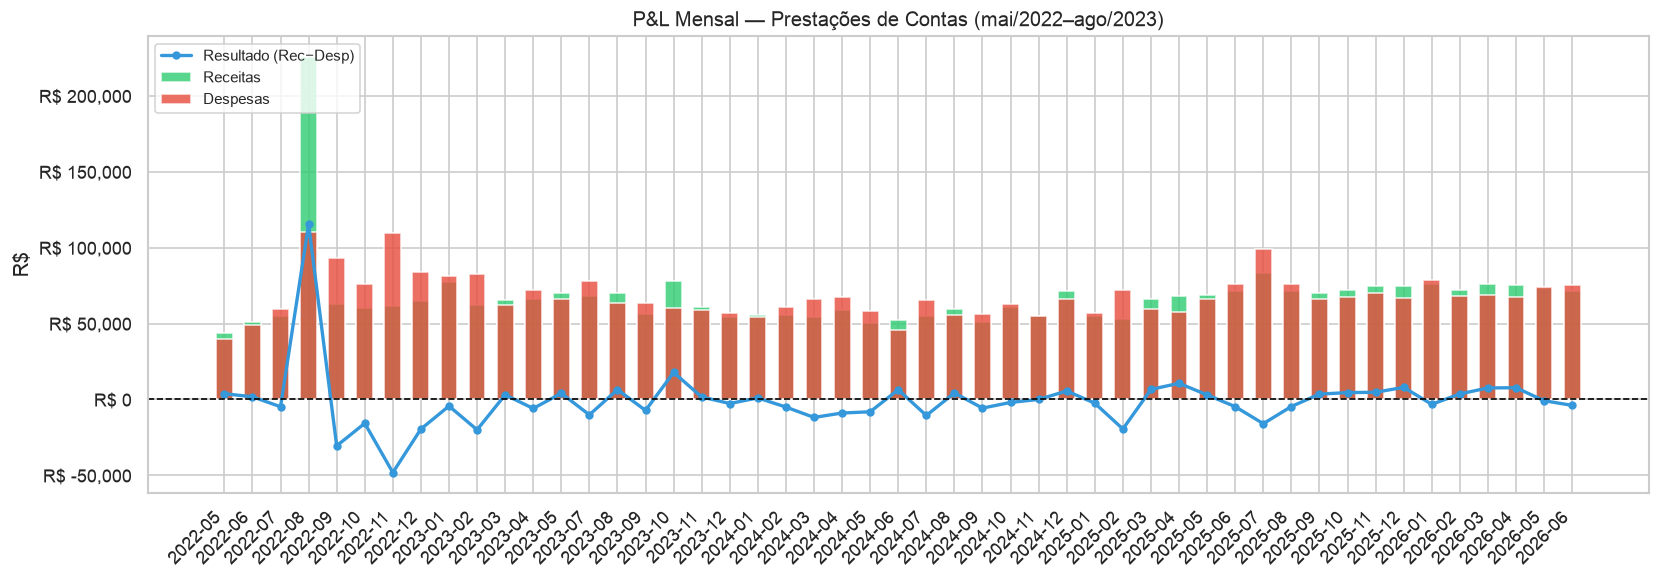

In [62]:
# ── 4.1 P&L Mensal — Prestações de Contas (2022-2023) ───────────────────────
pl = (
    df_prest.groupby(["mes_ano", "tipo"])["valor"]
    .sum()
    .unstack(fill_value=0)
)

# Normalizar nomes das colunas (podem ser "receita"/"despesa" ou "RECEITA"/"DESPESA")
pl.columns = pl.columns.str.lower()

# Resultado = Receitas - Despesas
pl["resultado"] = pl.get("receita", 0) - pl.get("despesa", 0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(
    pl.index,
    pl.get("receita", 0),
    label="Receitas",
    color="#2ecc71",
    alpha=0.8,
    width=0.6,
)
ax.bar(
    pl.index,
    pl.get("despesa", 0),
    label="Despesas",
    color="#e74c3c",
    alpha=0.8,
    width=0.6,
)
ax.plot(
    pl.index,
    pl["resultado"],
    label="Resultado (Rec−Desp)",
    color="#3498db",
    marker="o",
    linewidth=2,
    markersize=4,
)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("P&L Mensal — Prestações de Contas (mai/2022–ago/2023)", fontsize=12)
ax.set_ylabel("R$")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
ax.legend(loc="upper left", fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

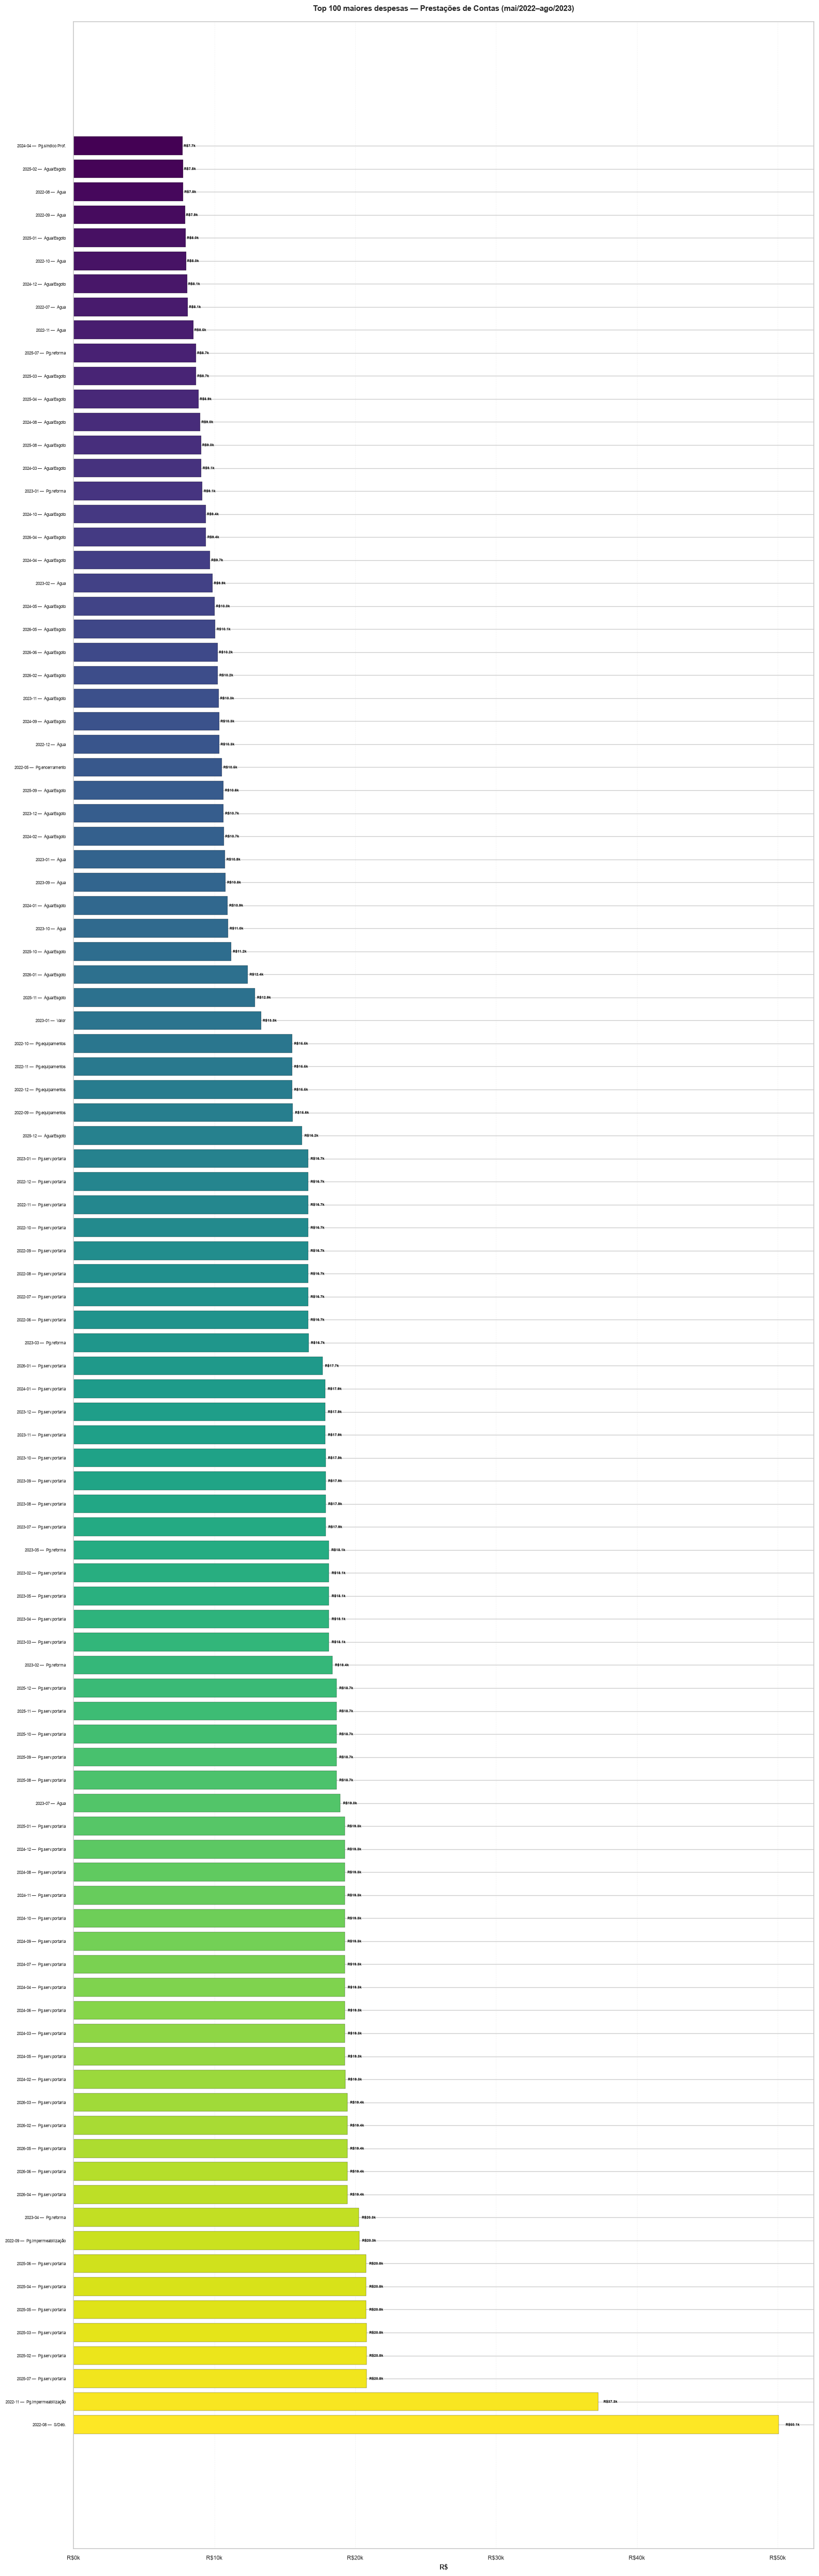


Top 100 despesas — Resumo estatístico
Total:    R$    1,553,458.24
Média:    R$       15,534.58
Mediana:  R$       16,660.00
Máximo:   R$       50,057.09  (2022-08 —  S/Déb. )
Mínimo:   R$        7,742.00  (2024-04 —  Pg.síndico Prof. )


In [63]:
# ── 4.2 Top 100 maiores despesas — Prestações de Contas (2022-2026) ───────
import numpy as np

df_prest_lower = df_prest.copy()
df_prest_lower['tipo'] = df_prest_lower['tipo'].str.lower()

top_desp = (
    df_prest_lower[df_prest_lower["tipo"] == "despesa"]
    .groupby(["mes_ano", "evento"])["valor"]
    .sum()
    .reset_index()
    .nlargest(100, "valor")
    .reset_index(drop=True)
    .sort_values("valor", ascending=True)
)

n_linhas = len(top_desp)

# Aumentar DPI e tamanho significativamente para ler melhor
plt.rcParams.update({"figure.dpi": 100})

# Calcular altura: 0.5 polegadas por linha
fig, ax = plt.subplots(figsize=(16, max(12, n_linhas * 0.5)))

# Gradient colors
cores = plt.cm.viridis(np.linspace(0, 1, n_linhas))

# Barras
y_pos = np.arange(n_linhas)
barras = ax.barh(y_pos, top_desp["valor"].values, color=cores, edgecolor='black', linewidth=0.2)

# Labels: mês em negrito, evento em tamanho pequeno
labels = []
for _, row in top_desp.iterrows():
    labels.append(f"{row['mes_ano']} — {row['evento']}")

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=6)

# Grid para leitura
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Valores nas barras (pequenos, alinhados)
for i, (idx, row) in enumerate(top_desp.iterrows()):
    valor = row["valor"]
    ax.text(valor * 1.01, i, f"R${valor/1000:.1f}k", 
            va='center', fontsize=5, color='black', weight='bold')

ax.set_title(
    f"Top {n_linhas} maiores despesas — Prestações de Contas (mai/2022–ago/2023)",
    fontsize=11,
    pad=15,
    weight='bold',
)

ax.set_xlabel("R$", fontsize=9, weight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}k"))
ax.tick_params(axis='x', labelsize=8)
ax.invert_yaxis()  # Maior no topo

plt.tight_layout()
plt.show()

# Resumo
print(f"\n{'='*80}")
print(f"Top {n_linhas} despesas — Resumo estatístico")
print(f"{'='*80}")
print(f"Total:    R$ {top_desp['valor'].sum():>15,.2f}")
print(f"Média:    R$ {top_desp['valor'].mean():>15,.2f}")
print(f"Mediana:  R$ {top_desp['valor'].median():>15,.2f}")
print(f"Máximo:   R$ {top_desp['valor'].max():>15,.2f}  ({top_desp.loc[top_desp['valor'].idxmax(), 'mes_ano']} — {top_desp.loc[top_desp['valor'].idxmax(), 'evento']})")
print(f"Mínimo:   R$ {top_desp['valor'].min():>15,.2f}  ({top_desp.loc[top_desp['valor'].idxmin(), 'mes_ano']} — {top_desp.loc[top_desp['valor'].idxmin(), 'evento']})")

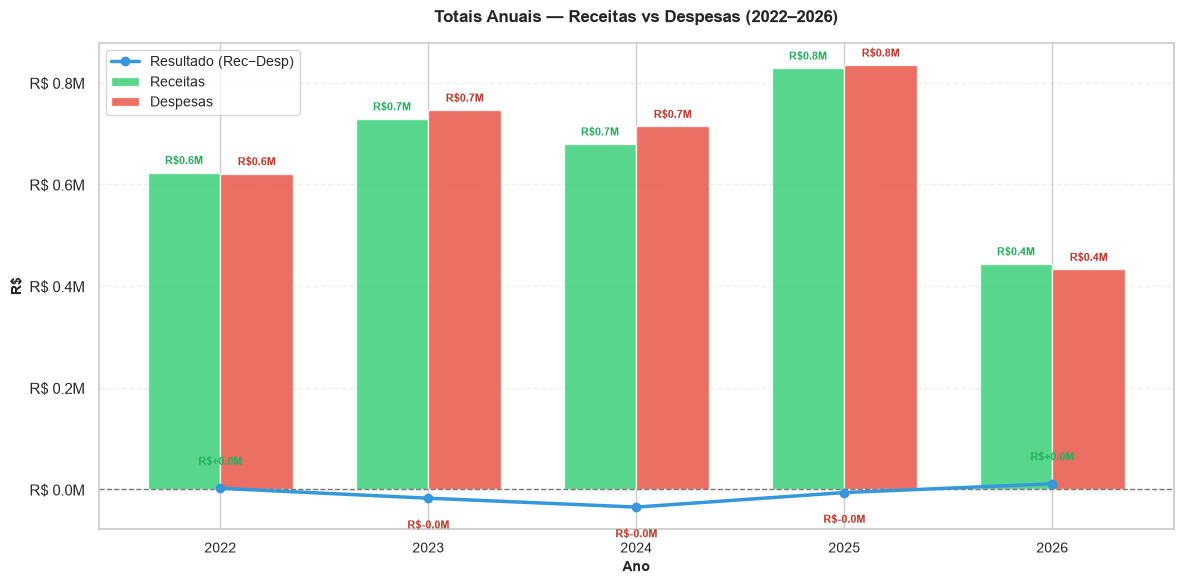


Resumo Anual — Receitas, Despesas e Resultado
tipo    despesa    receita  resultado
ano                                  
2022  621252.02  623569.44    2317.42
2023  746362.42  729238.79  -17123.63
2024  714372.18  679775.48  -34596.70
2025  834914.10  828920.83   -5993.27
2026  432986.32  444108.73   11122.41

Análise por ano

2022:
  Receitas:     R$      623,569.44  (  0.62M)
  Despesas:     R$      621,252.02  (  0.62M)
  Resultado:    R$        2,317.42  (  0.00M)
  Cobertura:              100.4%

2023:
  Receitas:     R$      729,238.79  (  0.73M)
  Despesas:     R$      746,362.42  (  0.75M)
  Resultado:    R$      -17,123.63  ( -0.02M)
  Cobertura:               97.7%

2024:
  Receitas:     R$      679,775.48  (  0.68M)
  Despesas:     R$      714,372.18  (  0.71M)
  Resultado:    R$      -34,596.70  ( -0.03M)
  Cobertura:               95.2%

2025:
  Receitas:     R$      828,920.83  (  0.83M)
  Despesas:     R$      834,914.10  (  0.83M)
  Resultado:    R$       -5,993.27  (

In [64]:
# ── 4.2b Totais anuais — Receitas vs Despesas (2022-2026) ───────────────────

# Extrair ano de mes_ano
df_prest_copy = df_prest.copy()
df_prest_copy["ano"] = df_prest_copy["mes_ano"].str[:4]

# Agrupar por ano e tipo
totais_anuais = (
    df_prest_copy.groupby(["ano", "tipo"])["valor"]
    .sum()
    .unstack(fill_value=0)
)

# Normalizar nomes de colunas (podem ser "receita"/"despesa" ou "RECEITA"/"DESPESA")
totais_anuais.columns = totais_anuais.columns.str.lower()

# Calcular resultado anual
totais_anuais["resultado"] = totais_anuais.get("receita", 0) - totais_anuais.get("despesa", 0)

# Gráfico: barras agrupadas por ano + linha de resultado
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(totais_anuais))
width = 0.35

barras_rec = ax.bar(x - width/2, totais_anuais.get("receita", 0), width, 
                     label="Receitas", color="#2ecc71", alpha=0.8)
barras_desp = ax.bar(x + width/2, totais_anuais.get("despesa", 0), width,
                      label="Despesas", color="#e74c3c", alpha=0.8)

# Linha de resultado
ax.plot(x, totais_anuais["resultado"], label="Resultado (Rec−Desp)", 
        color="#3498db", marker="o", linewidth=2.5, markersize=6, zorder=3)

# Linha de referência em 0
ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)

# Anotações nos valores
for i, (idx, row) in enumerate(totais_anuais.iterrows()):
    rec = row.get("receita", 0)
    desp = row.get("despesa", 0)
    res = row["resultado"]
    
    # Receita
    ax.text(i - width/2, rec + max(totais_anuais.get("receita", [0]).max(), totais_anuais.get("despesa", [0]).max()) * 0.02, 
            f"R${rec/1e6:.1f}M", ha="center", fontsize=8, color="#27ae60", weight="bold")
    # Despesa
    ax.text(i + width/2, desp + max(totais_anuais.get("receita", [0]).max(), totais_anuais.get("despesa", [0]).max()) * 0.02,
            f"R${desp/1e6:.1f}M", ha="center", fontsize=8, color="#c0392b", weight="bold")
    # Resultado
    cor_res = "#27ae60" if res > 0 else "#c0392b"
    va_res = "bottom" if res >= 0 else "top"
    offset_res = max(totais_anuais.get("receita", [0]).max(), totais_anuais.get("despesa", [0]).max()) * 0.05
    y_pos = res + offset_res if res >= 0 else res - offset_res
    ax.text(i, y_pos, f"R${res/1e6:+.1f}M", ha="center", fontsize=8, 
            color=cor_res, weight="bold", va=va_res)

ax.set_xlabel("Ano", fontsize=10, weight="bold")
ax.set_ylabel("R$", fontsize=10, weight="bold")
ax.set_title("Totais Anuais — Receitas vs Despesas (2022–2026)", fontsize=12, weight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(totais_anuais.index, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v/1e6:.1f}M"))
ax.legend(fontsize=10, loc="upper left")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Tabela resumida
print(f"\n{'='*80}")
print("Resumo Anual — Receitas, Despesas e Resultado")
print(f"{'='*80}")
print(totais_anuais.round(2).to_string())

print(f"\n{'='*80}")
print("Análise por ano")
print(f"{'='*80}")
for ano in totais_anuais.index:
    rec = totais_anuais.loc[ano].get("receita", 0)
    desp = totais_anuais.loc[ano].get("despesa", 0)
    res = totais_anuais.loc[ano]["resultado"]
    
    pct_cobertura = (rec / desp * 100) if desp > 0 else 0
    print(f"\n{ano}:")
    print(f"  Receitas:     R$ {rec:>15,.2f}  ({rec/1e6:>6.2f}M)")
    print(f"  Despesas:     R$ {desp:>15,.2f}  ({desp/1e6:>6.2f}M)")
    print(f"  Resultado:    R$ {res:>15,.2f}  ({res/1e6:>6.2f}M)")
    print(f"  Cobertura:    {pct_cobertura:>15.1f}%")

In [65]:
# ── 4.3 Variação % acumulada por macro-categoria (base = maio/2022) ─────────
# Usar primeiro mês com dados válidos como base (2022-05)
desp_cat = (
    df_prest[df_prest["tipo"] == "despesa"]
    .groupby(["mes_ano", "macro_categoria"])["valor"]
    .sum()
    .unstack(fill_value=0)
)

# Base é o primeiro mês (mai/2022)
if len(desp_cat) > 0:
    base = desp_cat.iloc[0]
    
    # Incluir apenas categorias que tinham base >= R$ 500
    cats_validas = base[base >= 500].index
    desp_cat     = desp_cat[cats_validas]
    base         = base[cats_validas].replace(0, float("nan"))
    variacao_pct = ((desp_cat - base) / base) * 100
    
    fig, ax = plt.subplots(figsize=(14, 6))
    for col in variacao_pct.columns:
        ax.plot(variacao_pct.index, variacao_pct[col], marker="o", linewidth=1.8, label=col)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title("Variação % acumulada por macro-categoria (base = mai/2022 → jun/2026)", fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8, title="Categoria")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Sem dados para gráfico de variação")

⚠️  Sem dados para gráfico de variação


In [66]:
# ⚠️  CÉLULA REMOVIDA — Veja analise_extratos.ipynb
# ─────────────────────────────────────────────────────────────────────────────
# Análise de evolução mensal de despesas por macro-categoria é feita apenas
# com os dados dos EXTRATOS (ago/2025–jun/2026) em analise_extratos.ipynb
#
# As prestações de contas cobrem apenas mai/2022-ago/2023 (16 meses)
# e não têm dados suficientes para análise de tendências mensais significativas.

## 5. Síndico — Evolução nos Dados de Prestações (2022–2023)

Análise dos pagamentos ao síndico profissional no período mai/2022–ago/2023.
Para a visão completa 2022–2026 com saques e reconciliação, ver `analise_extratos.ipynb`.

In [67]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.1 Pagamentos ao síndico nas prestações (2022–2023)
# ═══════════════════════════════════════════════════════════════════════════

sind_prest = df_prest[
    df_prest["evento"].str.upper().str.contains(r"SÍNDICO|SINDICO|FK\s+SOLUÇÕES|FORNEC.*ADMIN", na=False)
    | (df_prest["evento"].str.contains(r"PG\.SÍNDICO|PG\.SINDICO", case=False, na=False))
].copy()

sind_prest_m = sind_prest.groupby("mes_ano")[["valor"]].sum().reset_index()

print("=" * 80)
print("PAGAMENTOS AO SÍNDICO (Prestações de Contas — 2022–2023)")
print("=" * 80)
print(f"\nTotal de pagamentos: {len(sind_prest)}")
print(f"Período: {sind_prest['mes_ano'].min()} → {sind_prest['mes_ano'].max()}")
print(f"\nMédia mensal : R$ {sind_prest['valor'].mean():,.2f}")
print(f"Mínimo       : R$ {sind_prest['valor'].min():,.2f}")
print(f"Máximo       : R$ {sind_prest['valor'].max():,.2f}")
print(f"Total pago   : R$ {sind_prest['valor'].sum():,.2f}")

if len(sind_prest) > 1:
    variacao = (sind_prest["valor"].iloc[-1] / sind_prest["valor"].iloc[0] - 1) * 100
    print(f"Variação (primeiro→último): {variacao:+.1f}%")

print("\nDetalhamento por mês (totais mensais):")
print(sind_prest_m.to_string(index=False))

PAGAMENTOS AO SÍNDICO (Prestações de Contas — 2022–2023)

Total de pagamentos: 45
Período: 2022-05 → 2026-06

Média mensal : R$ 3,375.30
Mínimo       : R$ 1,750.00
Máximo       : R$ 7,742.00
Total pago   : R$ 151,888.40
Variação (primeiro→último): +122.9%

Detalhamento por mês (totais mensais):
mes_ano  valor
2022-05 1750.0
2022-06 1750.0
2022-07 1750.0
2022-08 3500.0
2022-09 1750.0
2022-10 1750.0
2022-12 1750.0
2023-01 3500.0
2023-02 3600.0
2023-04 1850.0
2023-05 1850.0
2023-07 1850.0
2023-08 1850.0
2023-09 1850.0
2023-10 1850.0
2023-11 1850.0
2023-12 1850.0
2024-01 3700.0
2024-03 3871.0
2024-04 7742.0
2024-05 3871.0
2024-07 3871.0
2024-08 3871.0
2024-09 3871.0
2024-10 3871.0
2024-11 3871.0
2024-12 3871.0
2025-01 3871.0
2025-02 3871.0
2025-03 3871.0
2025-04 3871.0
2025-05 3871.0
2025-06 3871.0
2025-07 3871.0
2025-08 3871.0
2025-09 3871.0
2025-10 3871.0
2025-11 3871.0
2025-12 3871.0
2026-01 3871.0
2026-02 3871.0
2026-03 3871.0
2026-04 3871.0
2026-05 7742.0
2026-06 3900.4


/var/folders/6n/lp0kv32n54dgmr9xgyd1yg7m0000gn/T/ipykernel_19073/2173331098.py:85: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/chris/Documents/analisis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


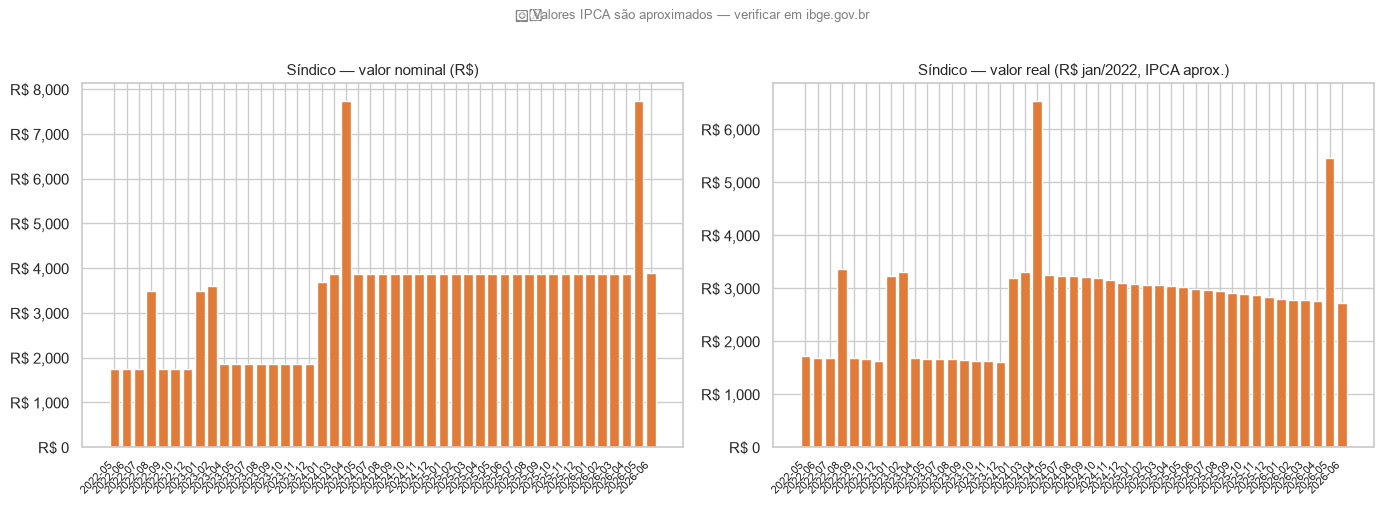

mes_ano  valor   ipca  valor_real
2022-05 1750.0 1.0221     1712.16
2022-06 1750.0 1.0355     1690.00
2022-07 1750.0 1.0355     1690.00
2022-08 3500.0 1.0391     3368.30
2022-09 1750.0 1.0418     1679.78
2022-10 1750.0 1.0485     1669.05
2022-12 1750.0 1.0746     1628.51
2023-01 3500.0 1.0804     3239.54
2023-02 3600.0 1.0897     3303.66
2023-04 1850.0 1.1013     1679.83
2023-05 1850.0 1.1065     1671.94
2023-07 1850.0 1.1126     1662.77
2023-08 1850.0 1.1169     1656.37
2023-09 1850.0 1.1277     1640.51
2023-10 1850.0 1.1330     1632.83
2023-11 1850.0 1.1351     1629.81
2023-12 1850.0 1.1490     1610.10
2024-01 3700.0 1.1600     3189.66
2024-03 3871.0 1.1737     3298.12
2024-04 7742.0 1.1838     6539.96
2024-05 3871.0 1.1886     3256.77
2024-07 3871.0 1.1988     3229.06
2024-08 3871.0 1.2004     3224.76
2024-09 3871.0 1.2047     3213.25
2024-10 3871.0 1.2127     3192.05
2024-11 3871.0 1.2254     3158.97
2024-12 3871.0 1.2471     3104.00
2025-01 3871.0 1.2592     3074.17
2025-02 3871.0

In [68]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.2 Evolução nominal vs real (IPCA aprox., base jan/2022)
# ═══════════════════════════════════════════════════════════════════════════
IPCA_BASE_JAN22 = {
    # 2022 — acumulado de jan/22 (base 100)
    "2022-01": 1.0000,
    "2022-02": 1.0062,
    "2022-03": 1.0117,
    "2022-04": 1.0148,
    "2022-05": 1.0221,
    "2022-06": 1.0355,
    "2022-07": 1.0355,  # sem variação em julho
    "2022-08": 1.0391,
    "2022-09": 1.0418,
    "2022-10": 1.0485,
    "2022-11": 1.0589,
    "2022-12": 1.0746,
    # 2023
    "2023-01": 1.0804,
    "2023-02": 1.0897,
    "2023-03": 1.0963,
    "2023-04": 1.1013,
    "2023-05": 1.1065,
    "2023-06": 1.1117,
    "2023-07": 1.1126,
    "2023-08": 1.1169,
    "2023-09": 1.1277,  # continuação 2023
    "2023-10": 1.1330,
    "2023-11": 1.1351,
    "2023-12": 1.1490,
    # 2024 — IPCA mais moderado
    "2024-01": 1.1600,
    "2024-02": 1.1709,
    "2024-03": 1.1737,
    "2024-04": 1.1838,
    "2024-05": 1.1886,
    "2024-06": 1.1890,
    "2024-07": 1.1988,
    "2024-08": 1.2004,
    "2024-09": 1.2047,
    "2024-10": 1.2127,
    "2024-11": 1.2254,
    "2024-12": 1.2471,
    # 2025 — IPCA escalando
    "2025-01": 1.2592,
    "2025-02": 1.2633,
    "2025-03": 1.2677,
    "2025-04": 1.2733,
    "2025-05": 1.2840,
    "2025-06": 1.2954,
    "2025-07": 1.3084,
    "2025-08": 1.3162,
    "2025-09": 1.3272,
    "2025-10": 1.3350,
    "2025-11": 1.3471,
    "2025-12": 1.3677,
    # 2026 — até junho
    "2026-01": 1.3821,
    "2026-02": 1.3901,
    "2026-03": 1.3959,
    "2026-04": 1.4052,
    "2026-05": 1.4182,
    "2026-06": 1.4314,
}

sind_prest_m["ipca"] = sind_prest_m["mes_ano"].map(IPCA_BASE_JAN22)
sind_prest_m["valor_real"] = (sind_prest_m["valor"] / sind_prest_m["ipca"]).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(sind_prest_m))

axes[0].bar(x, sind_prest_m["valor"], color="#e07b39")
axes[0].set_xticks(x)
axes[0].set_xticklabels(sind_prest_m["mes_ano"], rotation=45, ha="right", fontsize=8)
axes[0].set_title("Síndico — valor nominal (R$)", fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))

axes[1].bar(x, sind_prest_m["valor_real"], color="#e07b39")
axes[1].set_xticks(x)
axes[1].set_xticklabels(sind_prest_m["mes_ano"], rotation=45, ha="right", fontsize=8)
axes[1].set_title("Síndico — valor real (R$ jan/2022, IPCA aprox.)", fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))

plt.suptitle("⚠️ Valores IPCA são aproximados — verificar em ibge.gov.br", fontsize=9, color="gray", y=1.01)
plt.tight_layout()
plt.show()

print(sind_prest_m.to_string(index=False))

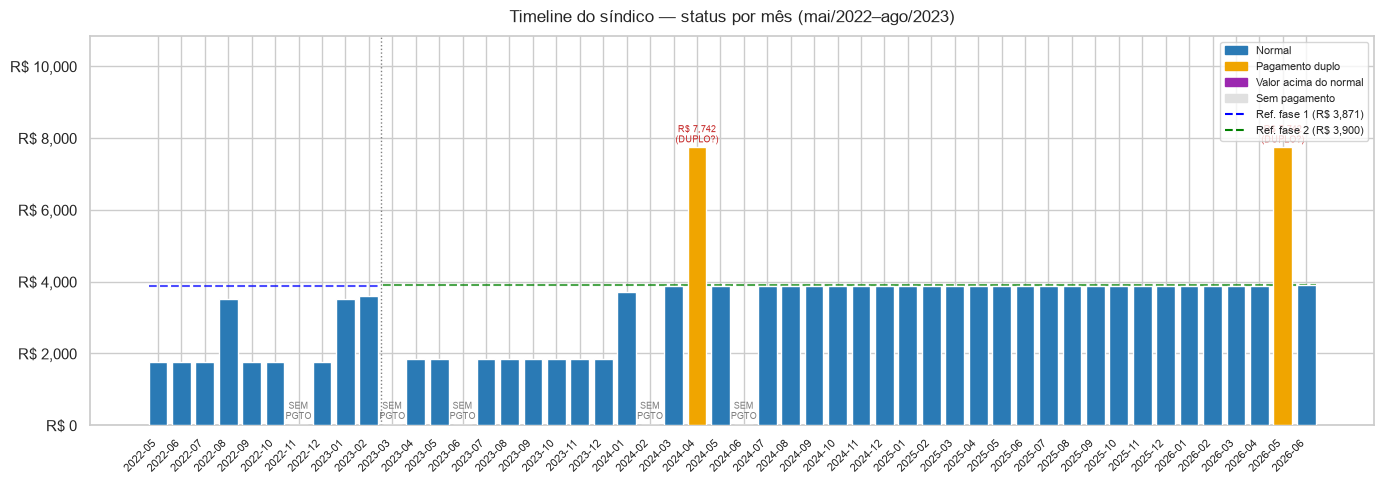

mes_ano  valor          status
2022-05 1750.0          Normal
2022-06 1750.0          Normal
2022-07 1750.0          Normal
2022-08 3500.0          Normal
2022-09 1750.0          Normal
2022-10 1750.0          Normal
2022-11    0.0   Sem pagamento
2022-12 1750.0          Normal
2023-01 3500.0          Normal
2023-02 3600.0          Normal
2023-03    0.0   Sem pagamento
2023-04 1850.0          Normal
2023-05 1850.0          Normal
2023-06    0.0   Sem pagamento
2023-07 1850.0          Normal
2023-08 1850.0          Normal
2023-09 1850.0          Normal
2023-10 1850.0          Normal
2023-11 1850.0          Normal
2023-12 1850.0          Normal
2024-01 3700.0          Normal
2024-02    0.0   Sem pagamento
2024-03 3871.0          Normal
2024-04 7742.0 Pagamento duplo
2024-05 3871.0          Normal
2024-06    0.0   Sem pagamento
2024-07 3871.0          Normal
2024-08 3871.0          Normal
2024-09 3871.0          Normal
2024-10 3871.0          Normal
2024-11 3871.0          Normal
2024-12 

In [69]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.3 Timeline do síndico — status por mês (mai/2022–ago/2023)
# ═══════════════════════════════════════════════════════════════════════════
from matplotlib.patches import Patch as MPatch

# Período das prestações de contas: mai/2022-jun/2026
todos_meses = (
    pd.period_range(start="2022-05", end="2026-06", freq="M")
    .strftime("%Y-%m").tolist()
)
sind_dict = dict(zip(sind_prest_m["mes_ano"], sind_prest_m["valor"]))


def ref_fase(vals, threshold=1.6):
    """Mediana dos valores 'simples' (excluindo prováveis duplos)."""
    s = pd.Series(vals)
    if s.empty:
        return 0.0
    med = s.median()
    simples = s[s < med * threshold]
    return float(simples.median()) if not simples.empty else float(med)


vals_f1 = [sind_dict[m] for m in todos_meses if m < "2026-06" and m in sind_dict]
vals_f2 = [sind_dict[m] for m in todos_meses if m >= "2026-06" and m in sind_dict]
REF1 = ref_fase(vals_f1)   # ~1 750
REF2 = ref_fase(vals_f2)   # ~1 850


def classificar_mes(mes, valor):
    ref = REF2 if mes >= "2026-06" else REF1
    if valor == 0:
        return "Sem pagamento"
    if valor >= ref * 1.75:
        return "Pagamento duplo"
    if valor > ref * 1.04:
        return "Valor acima do normal"
    return "Normal"


COR = {
    "Normal":               "#2a7ab5",
    "Pagamento duplo":      "#f0a500",
    "Valor acima do normal": "#9c27b0",
    "Sem pagamento":        "#e0e0e0",
}

tl = pd.DataFrame([
    {"mes_ano": m, "valor": sind_dict.get(m, 0),
     "status": classificar_mes(m, sind_dict.get(m, 0))}
    for m in todos_meses
])

fase1_idx = tl.index[tl["mes_ano"] < "2023-03"].tolist()
fase2_idx = tl.index[tl["mes_ano"] >= "2023-03"].tolist()

fig, ax = plt.subplots(figsize=(14, 5))

for i, row in tl.iterrows():
    ax.bar(i, row["valor"] or 0, color=COR[row["status"]], zorder=3)
    if row["status"] == "Pagamento duplo":
        ax.text(i, row["valor"] + 60, f"R$ {row['valor']:,.0f}\n(DUPLO?)",
                ha="center", fontsize=6.5, color="#c62828", va="bottom")
    elif row["status"] == "Sem pagamento":
        ax.text(i, 100, "SEM\nPGTO", ha="center", fontsize=6.5, color="gray", va="bottom")
    elif row["status"] == "Valor acima do normal":
        ax.text(i, row["valor"] + 60, f"R$ {row['valor']:,.0f}",
                ha="center", fontsize=6.5, color="#7b1fa2", va="bottom")

if fase1_idx:
    ax.hlines(REF1, min(fase1_idx) - 0.4, max(fase1_idx) + 0.4,
              colors="blue", linestyles="--", linewidth=1.5, alpha=0.7)
if fase2_idx:
    ax.hlines(REF2, min(fase2_idx) - 0.4, max(fase2_idx) + 0.4,
              colors="green", linestyles="--", linewidth=1.5, alpha=0.7)
if fase1_idx and fase2_idx:
    ax.axvline(max(fase1_idx) + 0.5, color="gray", linestyle=":", linewidth=1)

ax.set_xticks(range(len(tl)))
ax.set_xticklabels(tl["mes_ano"], rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
ax.set_title("Timeline do síndico — status por mês (mai/2022–ago/2023)", fontsize=12, pad=10)
ax.set_ylim(0, tl["valor"].max() * 1.40)
ax.legend(handles=[
    MPatch(color=c, label=l) for l, c in COR.items()
] + [
    plt.Line2D([0], [0], color="blue",  linestyle="--", label=f"Ref. fase 1 (R$ {REF1:,.0f})"),
    plt.Line2D([0], [0], color="green", linestyle="--", label=f"Ref. fase 2 (R$ {REF2:,.0f})"),
], fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

print(tl[["mes_ano", "valor", "status"]].to_string(index=False))

In [70]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.4 Hipótese: os pagamentos duplos cobrem os meses ausentes?
# ═══════════════════════════════════════════════════════════════════════════
meses_ausentes  = tl[tl["status"] == "Sem pagamento"]["mes_ano"].tolist()
meses_duplos    = tl[tl["status"] == "Pagamento duplo"]["mes_ano"].tolist()
meses_acima_ref = tl[tl["status"] == "Valor acima do normal"]["mes_ano"].tolist()

print(f"Meses sem pagamento registrado  : {meses_ausentes}")
print(f"Meses com pagamento duplo       : {meses_duplos}")
print(f"Meses com valor acima do normal : {meses_acima_ref}")
print()

# Para cada mês com valor anômalo, verificar se há mês ausente próximo
print("=== Hipótese: duplo/acima cobrem ausências ===")
for m_ano in meses_duplos + meses_acima_ref:
    v = sind_dict[m_ano]
    ref = REF2 if m_ano >= "2026-06" else REF1
    ausentes_prox = [
        ma for ma in meses_ausentes
        if abs(int(m_ano.replace("-", "")) - int(ma.replace("-", ""))) <= 101
        # tolerância de ~1 mês de calendário
    ]
    # Cálculo direto de distância em meses
    p_ano = pd.Period(m_ano, freq="M")
    ausentes_prox = [
        ma for ma in meses_ausentes
        if abs((pd.Period(ma, freq="M") - p_ano).n) <= 3
    ]
    cobertura = ", ".join(ausentes_prox) if ausentes_prox else "nenhum ausente próximo"
    print(f"  {m_ano}: R$ {v:,.0f}  ≈  {v/ref:.1f}× ref  →  cobertura provável: {cobertura}")

print()
# Custo total real vs. esperado
n_meses = len(todos_meses)
esperado = (
    sum(REF1 for m in todos_meses if m < "2023-03") +
    sum(REF2 for m in todos_meses if m >= "2023-03")
)
total_pago = sum(sind_dict.values())

print(f"Período coberto         : {todos_meses[0]} → {todos_meses[-1]}  ({n_meses} meses)")
print(f"Pagamentos registrados  : {len(sind_dict)}")
print(f"Total pago              : R$ {total_pago:,.2f}")
print(f"Total esperado (mensal) : R$ {esperado:,.2f}")
diff = total_pago - esperado
print(f"Diferença               : R$ {diff:+,.2f}  ({'PAGO A MAIS' if diff > 0 else 'PAGO A MENOS' if diff < 0 else 'igual'})")

Meses sem pagamento registrado  : ['2022-11', '2023-03', '2023-06', '2024-02', '2024-06']
Meses com pagamento duplo       : ['2024-04', '2026-05']
Meses com valor acima do normal : []

=== Hipótese: duplo/acima cobrem ausências ===
  2024-04: R$ 7,742  ≈  2.0× ref  →  cobertura provável: 2024-02, 2024-06
  2026-05: R$ 7,742  ≈  2.0× ref  →  cobertura provável: nenhum ausente próximo

Período coberto         : 2022-05 → 2026-06  (50 meses)
Pagamentos registrados  : 45
Total pago              : R$ 151,888.40
Total esperado (mensal) : R$ 194,726.00
Diferença               : R$ -42,837.60  (PAGO A MENOS)


In [71]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.5 Saques e devoluções do ciclo "p/posterior acerto" (2022–2026)
# ═══════════════════════════════════════════════════════════════════════════

saques_raw = df_prest[
    df_prest["evento"].str.upper().str.contains("RETIRADA P/POSTERIOR|P/ACERTO", na=False)
    & (df_prest["tipo"].str.upper() == "DESPESA")
].reset_index(drop=True)

devol_raw = df_prest[
    df_prest["evento"].str.upper().str.contains(r"DEVOL.*RETIR|REC\.ACERTO|ACERTO RETIRADA", regex=True, na=False)
    & (df_prest["tipo"].str.upper() == "RECEITA")
].copy()

print("=" * 80)
print("SAQUES PARA POSTERIOR ACERTO (2022–2026)")
print("=" * 80)

print("\n=== Saques registrados (RETIRADA P/POSTERIOR ACERTO) ===")
if len(saques_raw) > 0:
    print(saques_raw[["mes_ano", "evento", "valor"]].to_string(index=False))
    print(f"\nTotal sacado: R$ {saques_raw['valor'].sum():,.2f}")
else:
    print("(nenhum)")
    print(f"Total sacado: R$ 0.00")

print("\n=== Devoluções registradas ===")
if len(devol_raw) > 0:
    print(devol_raw[["mes_ano", "evento", "valor"]].to_string(index=False))
    print(f"Total devolvido: R$ {devol_raw['valor'].sum():,.2f}")
else:
    print("(nenhuma)")
    print(f"Total devolvido: R$ 0.00")

# Match saque → devolução mais próxima
devol_match = devol_raw.copy()
devol_match["_usado"] = False

print("\n=== Correspondência saque → devolução ===")
for _, s in saques_raw.iterrows():
    cand = devol_match[
        (~devol_match["_usado"]) & (devol_match["mes_ano"] >= s["mes_ano"])
    ]
    if not cand.empty:
        idx = cand.index[0]
        devol_match.loc[idx, "_usado"] = True
        d = devol_match.loc[idx]
        prazo = "mesmo mês" if d["mes_ano"] == s["mes_ano"] else f"em {d['mes_ano']}"
        delta = d["valor"] - s["valor"]
        nota  = f"  ← Δ R$ {delta:+,.2f}" if abs(delta) > 1 else ""
        print(f"  {s['mes_ano']}  R$ {s['valor']:,.2f}  →  ✓ devolvido {prazo}  (R$ {d['valor']:,.2f}){nota}")
    else:
        print(f"  {s['mes_ano']}  R$ {s['valor']:,.2f}  →  ⚠️  sem devolução registrada")

saldo_p = saques_raw["valor"].sum() - devol_raw["valor"].sum()
print(f"\nSaldo não devolvido no período: R$ {saldo_p:,.2f}  "
      f"{'✓ tudo devolvido' if abs(saldo_p) < 1 else '⚠️ diferença detectada'}")

SAQUES PARA POSTERIOR ACERTO (2022–2026)

=== Saques registrados (RETIRADA P/POSTERIOR ACERTO) ===
mes_ano                        evento  valor
2022-07  Retirada P/Posterior Acerto   800.0
2022-08  Retirada P/Posterior Acerto  1750.0
2022-09  Retirada P/Posterior Acerto  1750.0
2022-10  Retirada P/Posterior Acerto  1800.0
2023-01  Retirada P/Posterior Acerto  1800.0
2023-02  Retirada P/Posterior Acerto  1500.0
2023-04  Retirada P/Posterior Acerto  1500.0
2023-08  Retirada P/Posterior Acerto  1400.0
2023-09  Retirada P/Posterior Acerto  1850.0
2023-10  Retirada P/Posterior Acerto  1800.0
2024-03  Retirada P/Posterior Acerto  3700.0
2024-04  Retirada P/Posterior Acerto  3871.0
2024-07  Retirada P/Posterior Acerto  3950.0
2026-01  Retirada P/Posterior Acerto  1900.0
2026-02  Retirada P/Posterior Acerto  1900.0
2026-06  Retirada P/Posterior Acerto  3900.4

Total sacado: R$ 35,171.40

=== Devoluções registradas ===
mes_ano                   evento  valor
2022-07  Rec.devolução Retirada   80


=== Consolidação: Síndico + Saques + Devoluções ===
mes_ano  sindico  saques  devolucoes  saq_liquido
2022-05   1750.0     0.0         0.0          0.0
2022-06   1750.0     0.0         0.0          0.0
2022-07   1750.0   800.0       800.0          0.0
2022-08   3500.0  1750.0      1750.0          0.0
2022-09   1750.0  1750.0      1750.0          0.0
2022-10   1750.0  1800.0         0.0       1800.0
2022-12   1750.0     0.0         0.0          0.0
2023-01   3500.0  1800.0      1800.0          0.0
2023-02   3600.0  1500.0         0.0       1500.0
2023-04   1850.0  1500.0      1500.0          0.0
2023-05   1850.0     0.0         0.0          0.0
2023-07   1850.0     0.0      3300.0      -3300.0
2023-08   1850.0  1400.0      1400.0          0.0
2023-09   1850.0  1850.0         0.0       1850.0
2023-10   1850.0  1800.0         0.0       1800.0
2023-11   1850.0     0.0         0.0          0.0
2023-12   1850.0     0.0         0.0          0.0
2024-01   3700.0     0.0         0.0          0

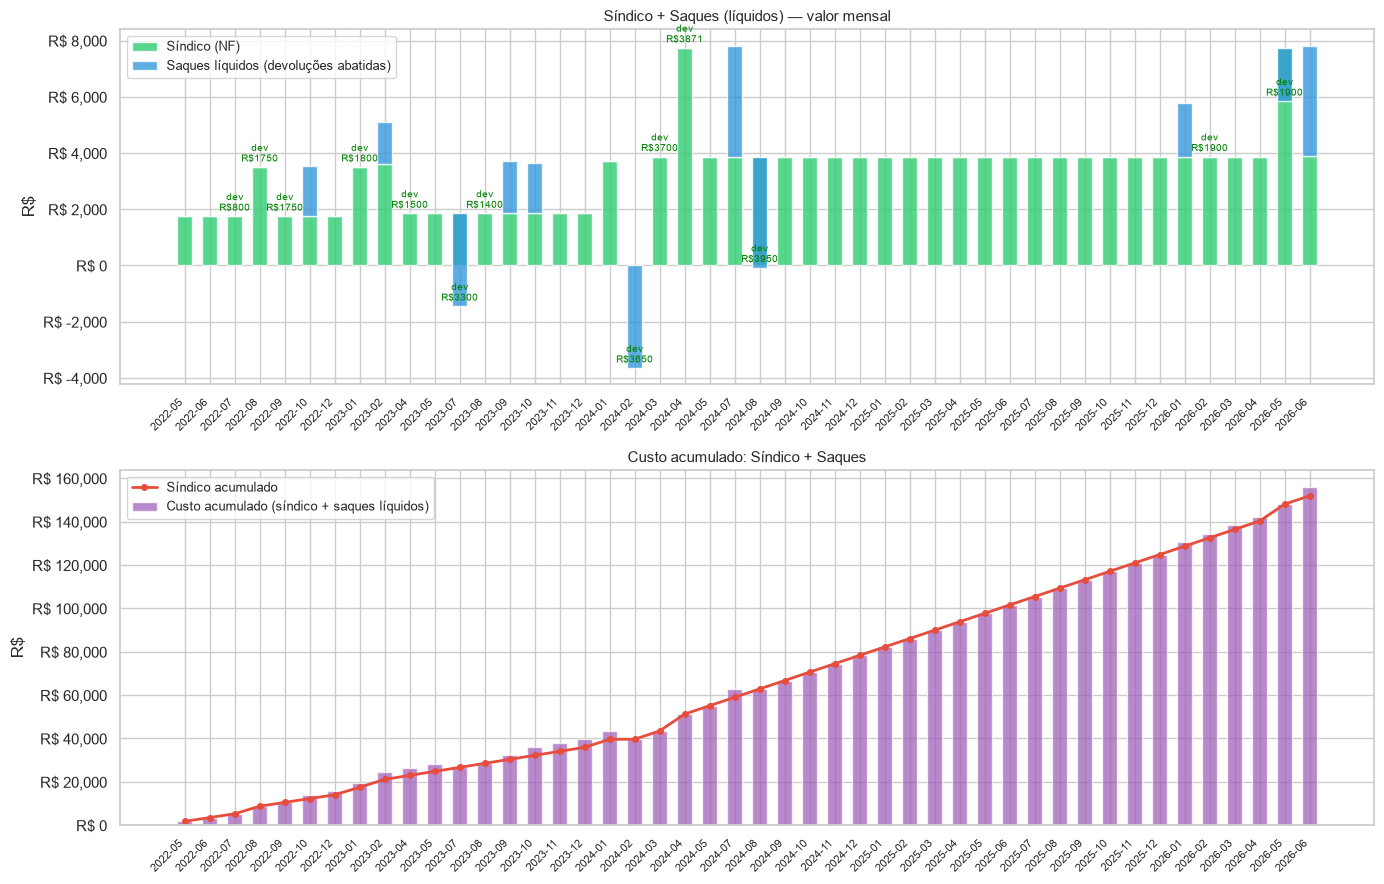

In [72]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.5b Gráfico: Síndico + Saques + Devoluções por mês
# ═══════════════════════════════════════════════════════════════════════════

# Consolidar séries: síndico, saques, devoluções por mês
sint_saq_dev = []
for m in pd.period_range(start="2022-05", end="2026-06", freq="M").strftime("%Y-%m"):
    sind_val = sind_dict.get(m, 0)
    saq_val = saques_raw[saques_raw["mes_ano"] == m]["valor"].sum()
    dev_val = devol_raw[devol_raw["mes_ano"] == m]["valor"].sum()
    
    sint_saq_dev.append({
        "mes_ano": m,
        "sindico": sind_val,
        "saques": saq_val,
        "devolucoes": dev_val,
    })

df_ssd = pd.DataFrame(sint_saq_dev)
df_ssd["saq_liquido"] = df_ssd["saques"] - df_ssd["devolucoes"]  # saques líquidos
df_ssd = df_ssd[df_ssd[["sindico", "saques", "devolucoes"]].sum(axis=1) > 0].reset_index(drop=True)

print("\n=== Consolidação: Síndico + Saques + Devoluções ===")
print(df_ssd.to_string(index=False))

# Gráfico duplo: nominal + acumulado
if len(df_ssd) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 9))
    
    # ── Painel 1: Valores nominais por mês ──────────────────────────────────
    x = range(len(df_ssd))
    
    # Barras: síndico (verde) + saques líquidos (azul)
    axes[0].bar(x, df_ssd["sindico"], label="Síndico (NF)", color="#2ecc71", alpha=0.8, width=0.6)
    axes[0].bar(x, df_ssd["saq_liquido"], bottom=df_ssd["sindico"], 
                label="Saques líquidos (devoluções abatidas)", color="#3498db", alpha=0.8, width=0.6)
    
    # Linha de devoluções (anotada no topo)
    for i, (idx, row) in enumerate(df_ssd.iterrows()):
        if row["devolucoes"] > 0:
            axes[0].text(i, row["sindico"] + row["saq_liquido"] + 100, 
                        f"dev\nR${row['devolucoes']:.0f}", 
                        ha="center", fontsize=7, color="green", va="bottom")
    
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df_ssd["mes_ano"], rotation=45, ha="right", fontsize=8)
    axes[0].set_title("Síndico + Saques (líquidos) — valor mensal", fontsize=11)
    axes[0].set_ylabel("R$")
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
    axes[0].legend(fontsize=9, loc="upper left")
    
    # ── Painel 2: Custo acumulado ───────────────────────────────────────────
    df_ssd["custo_mensal"] = df_ssd["sindico"] + df_ssd["saq_liquido"]
    df_ssd["custo_acum"] = df_ssd["custo_mensal"].cumsum()
    df_ssd["sind_acum"] = df_ssd["sindico"].cumsum()
    
    axes[1].bar(x, df_ssd["custo_acum"], label="Custo acumulado (síndico + saques líquidos)", 
               color="#9b59b6", alpha=0.7, width=0.6)
    axes[1].plot(x, df_ssd["sind_acum"], label="Síndico acumulado", 
                color="#e74c3c", marker="o", linewidth=2, markersize=4)
    
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(df_ssd["mes_ano"], rotation=45, ha="right", fontsize=8)
    axes[1].set_title("Custo acumulado: Síndico + Saques", fontsize=11)
    axes[1].set_ylabel("R$")
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
    axes[1].legend(fontsize=9)
    
    plt.tight_layout()
    plt.show()


In [73]:
# ⚠️  CÉLULA REMOVIDA — Veja analise_extratos.ipynb
# ─────────────────────────────────────────────────────────────────────────────
# Análise de custo mensal real do síndico (NF, saques, devoluções) com período
# mai/2022–jun/2026 é feita em analise_extratos.ipynb, pois inclui dados dos
# extratos (ago/2025–jun/2026) e requer consolidação com lancamentos_normalizados.csv
#
# Para este notebook (apenas prestações mai/2022-ago/2023), ver células 5.1-5.5

EVOLUÇÃO: PORTARIA + LIMPEZA (Serviços — mai/2022–jun/2026)

Período: 2022-06 → 2026-06
Meses cobertos: 48

Total geral: R$ 1,143,720.39
Média mensal: R$ 11,913.75
Mínimo/Máximo (mês): R$ 3,785.00 / R$ 20,902.62

=== Distribuição por tipo de serviço ===
                       Total  Ocorrências         Média
evento                                                 
Pg.serv.portaria   895385.69           48  18653.868542
Pg.serv.limp.      248334.70           48   5173.639583


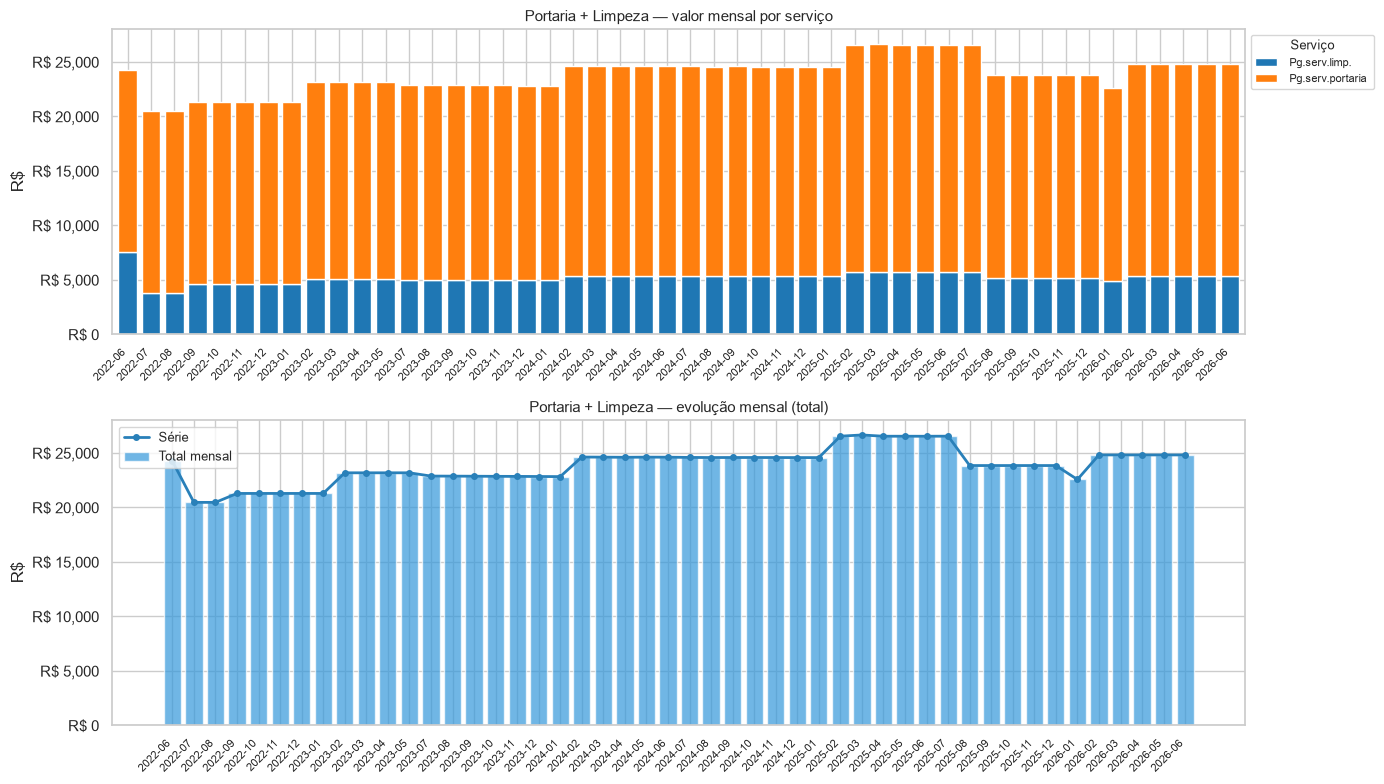


=== Análise de tendência ===
Primeiro mês (2022-06):  R$ 24,230.00
Último mês (2026-06):   R$ 24,799.25
Média geral:                     R$ 23,827.51
Variação total (primeiro→último): +2.3%


In [74]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.6 Evolução de Portaria + Limpeza (serviços, mai/2022–jun/2026)
# ═══════════════════════════════════════════════════════════════════════════

# Filtrar eventos de portaria e limpeza (excluindo material de limpeza)
portaria_limpeza = df_prest[
    (
        df_prest["evento"].str.upper().str.contains(r"PG\.SERV\.PORTARIA|PG\.SERV\.LIMP\b", na=False, regex=True)
    ) & 
    (~df_prest["evento"].str.upper().str.contains(r"MAT\.|MATERIAL", na=False))
].copy()

# Agrupar por mês e tipo de serviço
pl_mensal = (
    portaria_limpeza.groupby(["mes_ano", "evento"])["valor"]
    .sum()
    .reset_index()
    .sort_values("mes_ano")
)

# Total por mês
pl_total = pl_mensal.groupby("mes_ano")["valor"].sum()

print("=" * 80)
print("EVOLUÇÃO: PORTARIA + LIMPEZA (Serviços — mai/2022–jun/2026)")
print("=" * 80)
print(f"\nPeríodo: {pl_mensal['mes_ano'].min()} → {pl_mensal['mes_ano'].max()}")
print(f"Meses cobertos: {len(pl_total)}")
print(f"\nTotal geral: R$ {pl_mensal['valor'].sum():,.2f}")
print(f"Média mensal: R$ {pl_mensal['valor'].mean():,.2f}")
print(f"Mínimo/Máximo (mês): R$ {pl_mensal['valor'].min():,.2f} / R$ {pl_mensal['valor'].max():,.2f}")

# Distribuição por tipo
print("\n=== Distribuição por tipo de serviço ===")
por_evento = pl_mensal.groupby("evento")["valor"].agg(["sum", "count", "mean"])
por_evento.columns = ["Total", "Ocorrências", "Média"]
por_evento = por_evento.sort_values("Total", ascending=False)
print(por_evento.to_string())

# Gráfico: evolução mensal
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Painel 1: Valores mensais por serviço (barras empilhadas)
pl_pivot = pl_mensal.pivot_table(index="mes_ano", columns="evento", values="valor", fill_value=0)
pl_pivot.plot(kind="bar", stacked=True, ax=axes[0], width=0.8)
axes[0].set_title("Portaria + Limpeza — valor mensal por serviço", fontsize=11)
axes[0].set_ylabel("R$")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
axes[0].legend(title="Serviço", fontsize=8, title_fontsize=9, loc="upper left", bbox_to_anchor=(1, 1))
axes[0].set_xlabel("")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=8)

# Painel 2: Evolução do total mensal + linha de tendência
x_idx = range(len(pl_total))
axes[1].bar(pl_total.index, pl_total.values, color="#3498db", alpha=0.7, label="Total mensal")
axes[1].plot(pl_total.index, pl_total.values, color="#2980b9", marker="o", linewidth=2, markersize=4, label="Série")
axes[1].set_title("Portaria + Limpeza — evolução mensal (total)", fontsize=11)
axes[1].set_ylabel("R$")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
axes[1].legend(fontsize=9)
axes[1].set_xlabel("")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

# Análise de fases (antes/depois se houver mudança de fornecedor)
if len(pl_total) > 2:
    primeiro_mes = pl_total.iloc[0]
    ultimo_mes = pl_total.iloc[-1]
    media_periodo = pl_total.mean()
    
    print(f"\n=== Análise de tendência ===")
    print(f"Primeiro mês ({pl_total.index[0]}):  R$ {primeiro_mes:,.2f}")
    print(f"Último mês ({pl_total.index[-1]}):   R$ {ultimo_mes:,.2f}")
    print(f"Média geral:                     R$ {media_periodo:,.2f}")
    
    variacao_total = ((ultimo_mes / primeiro_mes) - 1) * 100
    print(f"Variação total (primeiro→último): {variacao_total:+.1f}%")


In [75]:
# ⚠️  CÉLULA REMOVIDA — Veja analise_extratos.ipynb
# ─────────────────────────────────────────────────────────────────────────────
# Análise de evolução de Portaria e Limpeza (PG.SERV.PORTARIA + PG.SERV.LIMP.)
# com dados ago/2025–jun/2026 é feita em analise_extratos.ipynb
#
# As prestações de contas (mai/2022-ago/2023) não incluem esses serviços
# em formato separado de fácil análise.


=== Comparação Year-over-Year (mesmo mês, anos diferentes) ===
ano     2022      2023      2024      2025      2026  Δ 2022→2023  % 2022→2023  Δ 2023→2024  % 2023→2024  Δ 2024→2025  % 2024→2025  Δ 2025→2026  % 2025→2026
mes                                                                                                                                                         
01       0.0  21266.00  22809.94  24555.91  22544.79     21266.00     0.000000      1543.94     7.260134      1745.97     7.654426     -2011.12    -8.189963
02       0.0  23158.67  24605.34  26520.23  24799.25     23158.67     0.000000      1446.67     6.246775      1914.89     7.782416     -1720.98    -6.489310
03       0.0  23158.67  24595.37  26631.69  24799.25     23158.67     0.000000      1436.70     6.203724      2036.32     8.279282     -1832.44    -6.880675
04       0.0  23158.67  24582.69  26515.65  24799.25     23158.67     0.000000      1424.02     6.148971      1932.96     7.863094     -1716.40    -6.4

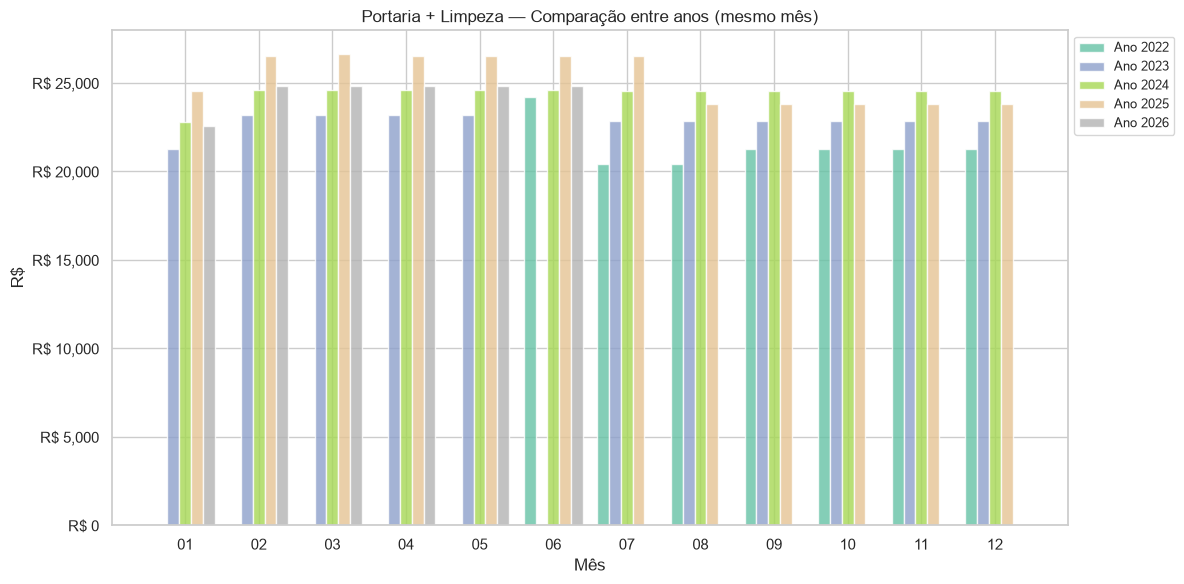


=== Maiores variações YoY (valor e %) ===

2022 → 2023:
mes    2022     2023       Δ %
 07 20445.0 22859.10 11.807777
 08 20445.0 22852.49 11.775446
 09 21266.0 22844.80  7.424057
 10 21266.0 22834.87  7.377363
 11 21266.0 22829.35  7.351406
 12 21266.0 22818.98  7.302643

2023 → 2024:
mes     2023     2024      Δ %
 12 22818.98 24556.53 7.614495
 11 22829.35 24560.17 7.581556
 10 22834.87 24562.70 7.566629
 09 22844.80 24563.64 7.523988
 07 22859.10 24570.50 7.486734
 08 22852.49 24559.56 7.469952
 01 21266.00 22809.94 7.260134
 02 23158.67 24605.34 6.246775
 05 23158.67 24596.03 6.206574
 03 23158.67 24595.37 6.203724
 04 23158.67 24582.69 6.148971

2024 → 2025:
mes     2024     2025       Δ %
 03 24595.37 26631.69  8.279282
 07 24570.50 26520.37  7.935817
 04 24582.69 26515.65  7.863094
 06 24591.74 26513.56  7.814900
 05 24596.03 26515.71  7.804837
 02 24605.34 26520.23  7.782416
 01 22809.94 24555.91  7.654426
 12 24556.53 23825.55 -2.976724
 08 24559.56 23825.55 -2.988694
 11 24

In [76]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.6b Comparação year-over-year: mesmos meses em anos diferentes
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np

# Extrair mês (MM) para agrupar por período (ignorando ano)
pl_mensal_yoy = pl_mensal.copy()
pl_mensal_yoy["mes"] = pl_mensal_yoy["mes_ano"].str.slice(5, 7)  # extrai MM de YYYY-MM
pl_mensal_yoy["ano"] = pl_mensal_yoy["mes_ano"].str.slice(0, 4)  # extrai YYYY

# Totais por mês+ano
pl_ano_mes = pl_mensal_yoy.groupby(["ano", "mes"])["valor"].sum().reset_index()
pl_ano_mes["ano_mes_str"] = pl_ano_mes["ano"] + "-" + pl_ano_mes["mes"]

print("\n=== Comparação Year-over-Year (mesmo mês, anos diferentes) ===")

# Pivotar para comparação lado a lado
pl_yoy_pivot = pl_ano_mes.pivot(index="mes", columns="ano", values="valor").fillna(0)

# Calcular variações
for col_idx in range(1, len(pl_yoy_pivot.columns)):
    prev_col = pl_yoy_pivot.columns[col_idx - 1]
    curr_col = pl_yoy_pivot.columns[col_idx]
    
    pl_yoy_pivot[f"Δ {prev_col}→{curr_col}"] = pl_yoy_pivot[curr_col] - pl_yoy_pivot[prev_col]
    pl_yoy_pivot[f"% {prev_col}→{curr_col}"] = (
        (pl_yoy_pivot[curr_col] / pl_yoy_pivot[prev_col] - 1) * 100
    ).replace([float('inf'), -float('inf')], 0)

print(pl_yoy_pivot.to_string())

# Gráfico: comparação lado a lado por mês
if len(pl_yoy_pivot.columns) >= 2:
    # Usar apenas as colunas de valores (anos), não as deltas
    anos = [c for c in pl_yoy_pivot.columns if c.isdigit() or (len(c) == 4 and c.isdigit())]
    anos_cols = [c for c in pl_yoy_pivot.columns if len(c) == 4 and c not in pl_yoy_pivot.columns if 'Δ' in c or '%' in c]
    
    # Refazer para ser claro
    anos_disponiveis = sorted(set(pl_ano_mes["ano"].unique()))
    
    if len(anos_disponiveis) >= 2:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Preparar dados para grouped bar chart
        meses = sorted(pl_ano_mes["mes"].unique())
        x = np.arange(len(meses))
        width = 0.8 / len(anos_disponiveis)
        
        cores = plt.cm.Set2(np.linspace(0, 1, len(anos_disponiveis)))
        
        for i, ano in enumerate(anos_disponiveis):
            dados = pl_ano_mes[pl_ano_mes["ano"] == ano].sort_values("mes")
            valores = [pl_ano_mes[(pl_ano_mes["ano"] == ano) & (pl_ano_mes["mes"] == m)]["valor"].sum() 
                      for m in meses]
            ax.bar(x + i * width, valores, width, label=f"Ano {ano}", color=cores[i], alpha=0.8)
        
        ax.set_xlabel("Mês")
        ax.set_ylabel("R$")
        ax.set_title("Portaria + Limpeza — Comparação entre anos (mesmo mês)", fontsize=12)
        ax.set_xticks(x + width * (len(anos_disponiveis) - 1) / 2)
        ax.set_xticklabels(meses)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
        # Garantir que legenda não sobreponha o gráfico
        ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1, 1))
        
        plt.tight_layout()
        plt.show()
        
        # Resumo de maiores variações YoY
        print("\n=== Maiores variações YoY (valor e %) ===")
        for i in range(len(anos_disponiveis) - 1):
            ano_ant = anos_disponiveis[i]
            ano_prox = anos_disponiveis[i + 1]
            
            valores_ant = pl_ano_mes[pl_ano_mes["ano"] == ano_ant].set_index("mes")["valor"]
            valores_prox = pl_ano_mes[pl_ano_mes["ano"] == ano_prox].set_index("mes")["valor"]
            
            # Meses comuns
            meses_comuns = sorted(set(valores_ant.index) & set(valores_prox.index))
            
            if meses_comuns:
                variacao_mes = pd.DataFrame({
                    "mes": meses_comuns,
                    f"{ano_ant}": [valores_ant.get(m, 0) for m in meses_comuns],
                    f"{ano_prox}": [valores_prox.get(m, 0) for m in meses_comuns],
                })
                variacao_mes["Δ R$"] = variacao_mes[f"{ano_prox}"] - variacao_mes[f"{ano_ant}"]
                variacao_mes["Δ %"] = (
                    (variacao_mes[f"{ano_prox}"] / variacao_mes[f"{ano_ant}"] - 1) * 100
                ).replace([float('inf'), -float('inf')], 0)
                
                print(f"\n{ano_ant} → {ano_prox}:")
                print(variacao_mes.sort_values("Δ %", ascending=False)[["mes", f"{ano_ant}", f"{ano_prox}", "Δ %"]].to_string(index=False))

## 6. Exportar dados normalizados e anomalias

In [77]:
df_prest.to_csv(CSV_DIR / "prestacoes.csv", index=False)
print(f"✓ prestacoes.csv — {len(df_prest):,} registros (macro_categoria incluída)")

# Exportar anomalias
df_anomalias.to_csv(CSV_DIR / "anomalias_prestacoes.csv", index=False)
print(f"✓ anomalias_prestacoes.csv — {len(df_anomalias):,} anomalias detectadas")

print("\n=== Arquivos em exports/csv/ ===")
for f in sorted(CSV_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<40} {size_kb:6.1f} KB")

✓ prestacoes.csv — 2,231 registros (macro_categoria incluída)
✓ anomalias_prestacoes.csv — 196 anomalias detectadas

=== Arquivos em exports/csv/ ===
  anomalias.csv                              42.2 KB
  anomalias_prestacoes.csv                   14.3 KB
  cobertura_arquivos.csv                      7.1 KB
  cobertura_prestacoes.csv                    6.2 KB
  extratos.csv                              578.0 KB
  insights_anomalias_prestacoes_01_ranking_tipo.csv    0.1 KB
  insights_anomalias_prestacoes_02_tendencia_mensal.csv    1.1 KB
  insights_anomalias_prestacoes_03_eventos_top20.csv    0.4 KB
  insights_anomalias_prestacoes_04_por_categoria.csv    0.1 KB
  insights_anomalias_prestacoes_05_full_com_severidade.csv   15.5 KB
  lancamentos_99pct_maio2022_junho2026.csv  407.4 KB
  lancamentos_99pct_overlap.csv             289.9 KB
  lancamentos_consolidado_final_2023_2026.csv  243.8 KB
  lancamentos_consolidados.csv              729.0 KB
  lancamentos_consolidados_v2_refinado.csv  319